In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#Prepare Dataset

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.29MB/s]


In [ ]:
#Adding noise
def add_noise(img, noise_factor=0.5):#noise factor is a scaling coefficient, increase/decrease amount of noise
    noisy = img + noise_factor * torch.randn_like(img) #torch.randn_like(img) generates random values ~ N(0,1) (mean 0, std 1), it is a tensor of the same shape as img
    noisy = torch.clamp(noisy, 0., 1.) #noisy images may have values below 0 and above 1, this function fixes this by clipping values to [0,1]
    return noisy

In [ ]:
# Autoencoder model
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),#first layer
            nn.ReLU(),
            nn.Linear(256, 64),#code/bottleneck layer
            nn.ReLU()
        )

#Input image is now represented as 64-dimensional vector

        self.decoder = nn.Sequential(
            nn.Linear(64, 256),  #Maps the 64-dimensional bottleneck vector back to 256 features(first step of reconstruction)
            nn.ReLU(),
            nn.Linear(256, 28*28), #Maps 256 features back to the original input dimension (the output is a flat vector representing the reconstructed image)
            nn.Sigmoid() #maps values between 0 and 1, matching the input image pixel range
        )



    def forward(self, x):
        encoded = self.encoder(x)  #Compress
        decoded = self.decoder(encoded) #reconstruction
        decoded = decoded.view(-1, 1, 28, 28) #Reshape to image format (batch_size, channels, height, width)
        return decoded



In [ ]:
model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)



In [ ]:
# Training loop
epochs = 5

for epoch in range(epochs):
    for img, _ in train_loader:
        img = img.to(device)

        noisy_img = add_noise(img)

        output = model(noisy_img)

        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")



Epoch [1/5], Loss: 0.0354
Epoch [2/5], Loss: 0.0269
Epoch [3/5], Loss: 0.0236
Epoch [4/5], Loss: 0.0220
Epoch [5/5], Loss: 0.0219


In [ ]:
#Testing
dataiter = iter(test_loader) #creates a Python iterator over the batches.
images, _ = next(dataiter) #next() gets the next batch from the iterator and - ignores labels.

noisy_imgs = add_noise(images).to(device)
outputs = model(noisy_imgs).cpu().detach() #matplotlib cannot handle GPU tensors, This function Denoise & move results back to CPU for plotting

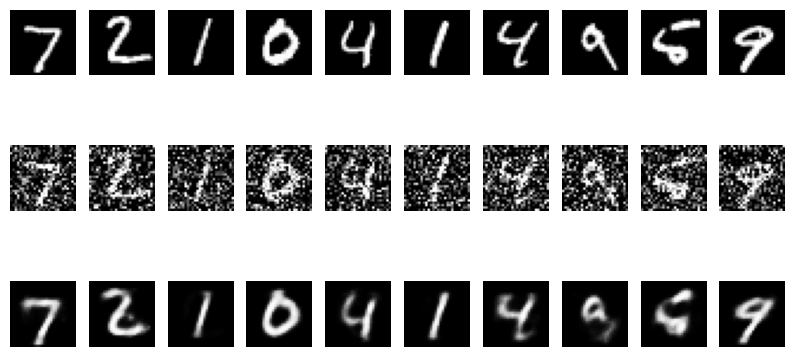

In [ ]:


# display images
fig, axes = plt.subplots(3, 10, figsize=(10,5))

for i in range(10):
    axes[0,i].imshow(images[i].squeeze(), cmap="gray") #squeeze() removes the channel dimension because imshow expects 2D
    axes[0,i].axis("off")

    axes[1,i].imshow(noisy_imgs.cpu()[i].squeeze(), cmap="gray")
    axes[1,i].axis("off")

    axes[2,i].imshow(outputs[i].squeeze(), cmap="gray")
    axes[2,i].axis("off")

axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Noisy")
axes[2,0].set_ylabel("Denoised")

plt.show()

In [ ]:
#we need to give noisy image as input and noisy output  to be trained in model. Then it shoul give use the correct output.

Epoch [1/5], Loss: 0.0910
Epoch [2/5], Loss: 0.0865
Epoch [3/5], Loss: 0.0856
Epoch [4/5], Loss: 0.0850
Epoch [5/5], Loss: 0.0847


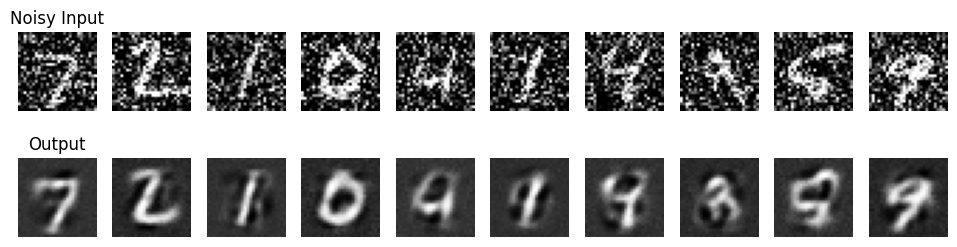

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)


def add_noise(img, noise_factor=0.5):
    noisy = img + noise_factor * torch.randn_like(img)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(-1, 1, 28, 28)
        return x

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


epochs = 5

for epoch in range(epochs):
    for img, _ in train_loader:
        img = img.to(device)

        noisy_img = add_noise(img)


        output = model(noisy_img)

        loss = criterion(output, noisy_img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


data_iter = iter(test_loader)
images, _ = next(data_iter)

images = images.to(device)

noisy_images = add_noise(images)

outputs = model(noisy_images).cpu().detach()


fig, axes = plt.subplots(2, 10, figsize=(12, 3))

for i in range(10):

    axes[0, i].imshow(noisy_images.cpu()[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(outputs[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0,0].set_title("Noisy Input")
axes[1,0].set_title("Output")

plt.show()